# Laboratory 6: Generating High-Resolution Images with Diffusion Models

This laboratory covers:

* The DDIM noise scheduler
* Adding the attention mechanism in denoising U-Net models
* Generating high-resolution images with diffusion models
* Interpolating initial noise tensors to generate composite images

In the previous two laboratories, we explored the fundamentals of diffusion models. We learned how these models use a forward diffusion process, where we gradually add noise to clean images until they are transformed into pure noise, and a reverse diffusion process, where a trained model reconstructs images by progressively removing noise. A key component of this process is the denoising U-Net model, which learns to clean up noisy images until the final output is indistinguishable from real images in the training dataset.

Once the model is trained, we can start with a completely random noise tensor and use the U-Net to iteratively remove noise, eventually generating a clear and meaningful image. Additionally, diffusion models can be conditioned on specific information—such as labels or text—to guide the image generation process. This conditional generation is crucial because modern text-to-image models rely on conditioning mechanisms to create images based on text prompts.

To keep things simple and computationally manageable, we used grayscale images of clothing items in the previous two laboratories. To generate high-resolution images, say, $64\times 64$ pixel RGB images, we need to build and train more advanced models due to the increased complexity of the data. In this laboratory, we will learn how to generate high-resolution color flower images using state-of-the-art diffusion techniques.

One key improvement we introduce is a new and more efficient noise scheduler, known as denoising diffusion implicit models (DDIM). In the previous laboratories, we worked with denoising diffusion probabilistic models (DDPM), which generate images through a randomized (stochastic) process and follow a Markovian process, meaning each step depends only on the immediate previous step. While effective, this method can require many steps to produce high-quality images.
In contrast, DDIM takes a more direct and predictable approach. It uses a deterministic, non-Markovian process, allowing it to generate images in fewer steps without sacrificing quality. This makes DDIM significantly more efficient than DDPM, an important advancement for generating high-resolution images quickly.

Compared to the simple U-Net model we built from scratch in Laboratory 5, we introduce two key improvements to the denoising U-Net model in this laboratory to enhance its ability to generate high-resolution images. One major improvement is the addition of more downsampling and upsampling layers in the U-Net. These extra layers allow the model to capture fine-grained details from the input image. Downsampling layers help the network break down the image into different levels of abstraction, identifying both high-level and low-level features. The upsampling layers then reconstruct the image by progressively refining these details, leading to a more realistic output.

However, increasing the model's depth and complexity also introduces a challenge: with so much information being processed, it becomes harder for the model to identify the most relevant features—like trying to find a needle in a haystack. Without an efficient way to focus on critical details, the model may struggle to generate clear and meaningful images. To address this challenge, we integrate the scaled dot product attention (SDPA) mechanism into the U-Net (the same attention mechanism we used in Laboratory 1 when translating German to English). Attention mechanisms allow the model to selectively focus on important features in an image while ignoring less relevant details.

Once we have trained our denoising model, we can generate high-resolution images by feeding an initial noise tensor into the U-Net. This noise tensor acts as a starting point, and the model gradually refines it into a clear, detailed image. Since the process is influenced by the specific noise tensor we provide, different initial noise tensors will result in different final images. For example, one noise tensor might lead to the generation of a white lily, while another might produce a yellow aster.
To illustrate how the choice of initial noise affects the final image, we will interpolate between two different noise tensors. This means we will blend the two noise tensors in varying proportions to create new, intermediate noise tensors. By assigning different weights to each original noise tensor, we can generate a smooth transition from one image to another.

For instance, if we start with a noise tensor that produces a white lily and another that produces a yellow aster, we can create a sequence of intermediate images by gradually shifting the balance between the two tensors. Feeding each of these blended noise tensors into the trained U-Net results in composite images that slowly change from one flower to the other. This step-by-step transition visually demonstrates how the initial noise influences the final output, reinforcing the core concept of controlled image generation in diffusion models.

# 1. Attention in U-Net, DDIM, and image interpolation

In this section, we will discuss the new features in the denoising U-Net model compared
to the one we used in the previous laboratory. We will add more downsampling and upsampling
layers and include the attention mechanism in the U-Net. This attention mechanism
helps the network focus on the most relevant parts of the image, such as shapes,
textures, or regions tied to the input prompt, so it can learn more effectively and generate
higher-quality results.

DDIM and DDPM are two types of noise schedulers used in diffusion models for
generative tasks. DDPM generates images through a randomized (stochastic) process
and follows a Markovian process, meaning each step depends only on the previous
step. While effective, this method requires many steps to produce high-quality images.
In contrast, DDIM uses a deterministic, non-Markovian process, allowing it to generate
images in fewer steps without sacrificing quality. This makes DDIM significantly
more efficient than DDPM, an important advancement for generating high-resolution
images quickly. While we have coded DDPM from scratch in the previous laboratory, we will
use DDIM in this laboratory and learn why it is more efficient than DDPM. Finally, we will
explain the role of the initial noise tensor in determining the final output in diffusion
models and how interpolating two initial noise tensors can lead to interpolated images.

## 1.1. Incorporating the attention mechanism in the U-Net model

Compared to the U-Net model we created in Laboratory 5, the U-Net model in this laboratory
has more layers and also incorporates the attention mechanism. The figure below is a diagram
of the components of the U-Net.

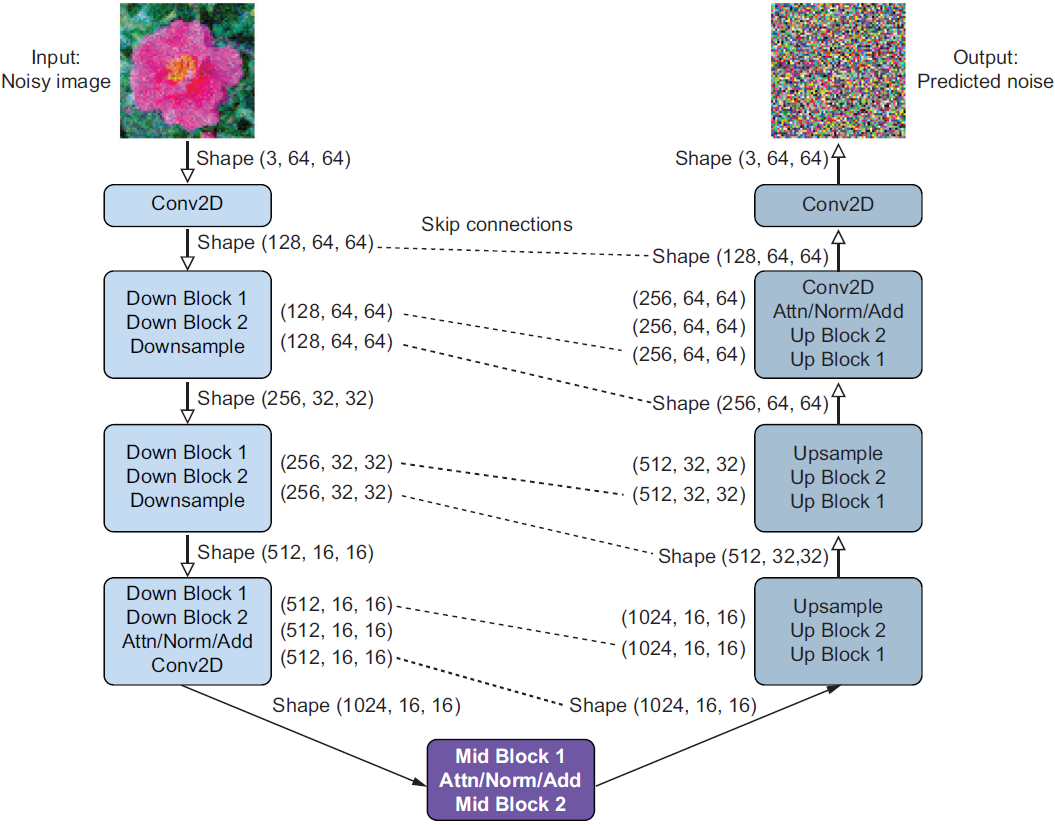

The top-left corner of the figure is a noisy image, which is the input to the denoising
U-Net. The U-Net predicts the noise in the image, based on which time step the noisy
image is in. Once we know the noise in the image, we can reconstruct the clean image
because the noisy image is a weighted sum of the original clean image and noise.

The noisy image goes through multiple down blocks in the contracting path (left
side of the figure), which consists of various convolutional layers and pooling layers.
The model extracts and encodes features at different levels of abstraction. The bottleneck
block (bottom of the figure) consists of convolutional layers, and it captures the
most abstract representations of the image. The expansive path (right side of the figure)
consists of multiple up blocks, which upsample the feature maps, reconstructing
the image. It does this by incorporating features from the contracting path through
skip connections (denoted by dashed lines in the figure).

Skip connections combine high-level, abstract features from the contracting path
with low-level, detailed features from the expansive path. This allows the U-Net model to better reconstruct fine details in the denoising process. However, skip connections
lead to redundant feature extractions in our denoising U-Net, which complicates the
identification of relevant features. The attention mechanism is needed so that the
model can learn to emphasize important features while disregarding irrelevant ones.

The attention mechanism is used in both the contracting and expansive paths (as
shown in the figure with the label Attn/Norm/Add). The attention mechanism is the
same as the one we used in Laboratory 1. However, in this context, the attention mechanism
is applied to image pixels instead of text tokens. Including the scaled dot-product
attention (SDPA) mechanism allows the model to weigh the importance of different
spatial regions dynamically. This is crucial for denoising tasks, where understanding the
broader context of the noisy data helps in predicting the clean data more accurately.

## 1.2. Denoising Diffusion Implicit Models

DDIM was first proposed by J. Song, C. Meng, and S. Ermon in 2020. The authors showed that while DDPMs have achieved high-quality image generation
without adversarial training, they require simulating a Markov chain for many
steps to produce a sample (in a Markov process, the future state depends only on the
present state and not on past states). For color images with high resolutions, this can
be extremely computationally intensive and time-consuming. DDIMs were shown as a
more efficient class of iterative implicit probabilistic models.

Song, Meng, and Ermon constructed a class of non-Markovian diffusion processes
that lead to the same training objective, but whose reverse process can be much
faster to sample from compared to DDPMs. They demonstrated that DDIMs can produce
high-quality samples $10$ to $50$ times faster compared to DDPMs. Further, DDPMs
use a stochastic sampling process, while DDIMs can use a deterministic approach.
DDIMs generally require fewer steps for sampling, making them more efficient.

DDIM's non-Markovian process allows for more flexibility in the denoising step. In
particular, Song, Meng, and Ermon show the reverse diffusion process as

\begin{equation}
\tag{1}
x_{t-1}=\sqrt{\bar{\alpha}_{t-1}}*(\text{predicted }x_{0})+(\text{direction pointing to }x_{t})+\sigma_{t}\epsilon_{t}.
\end{equation}

In this equation, $\epsilon_t$ follows a standard normal distribution, and $\sigma_t$ governs how much
random noise is in the reverse diffusion process. Recall that $x_0$ is the clean image at
time step $0$. A special case is when $\sigma_t = 0$, and the reverse diffusion process becomes
deterministic: this is the setting used in deterministic DDIM sampling, which enables
faster image generation by skipping stochastic noise and following a fixed trajectory
through the latent space.

## 1.3. Image interpolation in diffusion models

Once the model is trained, we feed an initial noise tensor to the U-Net, which refines
the noise tensor into a structured and detailed image. Because the output is influenced by the specific noise tensor provided at the start, different noise inputs lead to different
final images. This property offers flexibility and variety in image generation, allowing
us to explore the relationship between the initial noise tensor and the final output.

In particular, this laboratory explores this relationship through interpolation between
different noise tensors. By blending two different noise tensors in varying proportions,
we can create a sequence of intermediate noise states, which in turn generate a series
of final images that gradually transition from one image to another. This technique
provides valuable insights into how the initial noise tensor affects generative outcomes,
demonstrating the nuanced control possible in diffusion-based image synthesis. The figure below illustrates how image interpolation works in diffusion models.

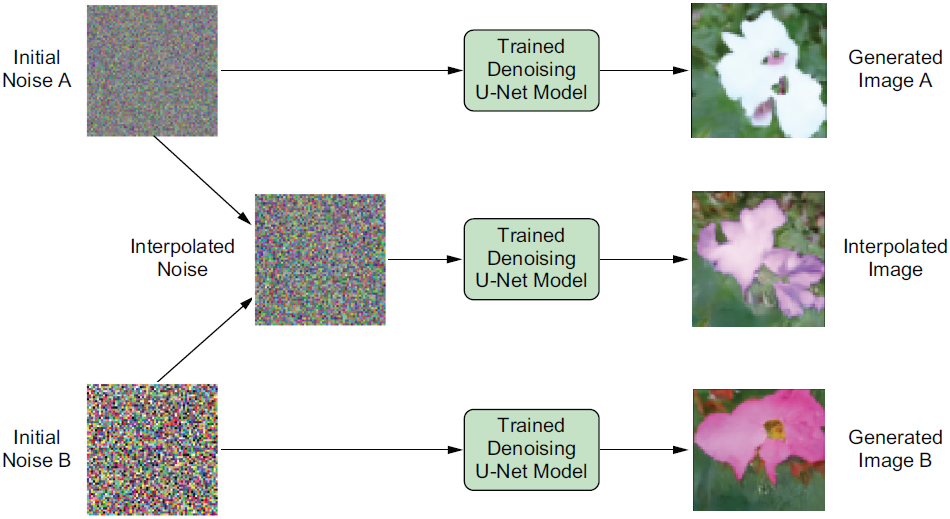

The top-left corner of the figure shows the initial noise tensor A. If we feed it to the
trained diffusion model, the final output is a white flower (image A, as shown at the
top-right corner of the figure). The bottom-left corner of the figure shows another
Initial Noise tensor, B. If we feed the noise tensor B to the trained diffusion model,
the final output is a red flower (image B in the bottom-right corner).

We can interpolate between two noise tensors. Interpolation involves blending two
different noise tensors in varying proportions to create a continuum of intermediate
noise states. Mathematically, if we have two noise tensors, $z_1$ and $z_2$, we can define an
interpolated noise tensor as

\begin{equation}
\tag{2}
z_{\alpha} = \alpha z_1 + (1-\alpha)z_2,
\end{equation}

where $\alpha$ is a blending coefficient that varies between $0$ and $1$. When $\alpha = 1$, the interpolated
tensor is identical to $z_1$, while $\alpha = 0$ results in $z_2$. For values of $\alpha$ between $0$ and $1$,
the resulting noise tensor represents a mixture of both original noise tensors, allowing
for a gradual transition from one image to another.

In the middle of the figure, we interpolate the initial noise tensors A and B by
placing equal weights on them (i.e., setting $\alpha = 0.5$ in equation (2)). We then feed the
interpolated noise tensor to the trained denoising U-Net model, and the output is an
image that has characteristics of both image A and image B (see middle-right in the figure).

Later, we will apply interpolation to image generation to create a sequence of images
that smoothly transition from one image to another. Suppose we start with two noise
tensors: one that produces an image of a white lily and another that produces an image
of a yellow aster. By generating images at different interpolation levels (e.g., $\alpha = 0.05$,
$0.15$, . . ., $0.95$), we obtain a set of composite images that change gradually from an
image similar to a lily to one similar to an aster.

Noise interpolation has several practical applications in generative AI and artistic
image synthesis. One benefit is controlled image generation: by adjusting the
interpolation parameter, we can exert fine-grained control over the generated output,
enabling the creation of hybrid images that incorporate elements from multiple
sources. It can also lead to smooth transitions in animation: interpolated noise
sequences can be used to generate animations that smoothly transition between different
visual concepts, providing a novel approach to AI-generated motion graphics.
Artists and designers can use noise interpolation to explore new creative possibilities,
generating variations of images that blend characteristics in unique and unexpected
ways.

# 2. High-resolution flower images as training data

To train the denoising U-Net model, we will use the Oxford 102 Flower dataset, which
contains roughly $8,000$ flower images. We will use the `datasets` library to download the
data from Hugging Face (a community that hosts and collaborates on AI models, datasets,
and applications). We will then visualize the images in the training
dataset and place the data in batches so that we can use them to train the denoising
U-Net model later.

Before we start, run
the following line of code to install several libraries that we will use:

In [ ]:
!pip install --upgrade datasets einops diffusers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 22.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


## 2.1.	Visualizing images in the training dataset

The `load_dataset()` method from the `datasets` library allows us to download the
Oxford 102 Flower dataset from Hugging Face directly, as shown in the following code.

In [ ]:
from datasets import load_dataset
from torchvision.transforms import (CenterCrop,
    Compose,InterpolationMode,RandomHorizontalFlip,
    Resize,ToTensor)

resolution=64

augmentations = Compose([
    Resize(resolution,
    interpolation=InterpolationMode.BILINEAR),
    CenterCrop(resolution),
    RandomHorizontalFlip(),
    ToTensor(),])    #Defines several image augmentation methods

def transforms(examples):
    images = [augmentations(image.convert("RGB"))
        for image in examples["image"]]
    return {"input": images}

dataset = load_dataset("huggan/flowers-102-categories",
    split="train",)    #Downloads the data from Hugging Face directly
dataset.set_transform(transforms)    #Performs image transformations

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/347M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8189 [00:00<?, ? examples/s]

After downloading the data from Hugging Face, we perform several image transformations
such as center crop (the central region of the image is extracted while the rest is
discarded) and random horizontal flip (creates a mirror image of the original image).
These image transformations and augmentations help our model learn more robust
and generalized representations from the training data, thus improving the quality of
the generated images.

To prepare for training, we place the dataset in batches of four. We can adjust the batch size
to two or even one (or switch to CPU training) if the GPU memory is small:

In [ ]:
import torch

torch.manual_seed(42)
batch_size=4
train_dataloader=torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True)

Next, we use the `matplotlib` library to visualize some examples of the flower images in the dataset:


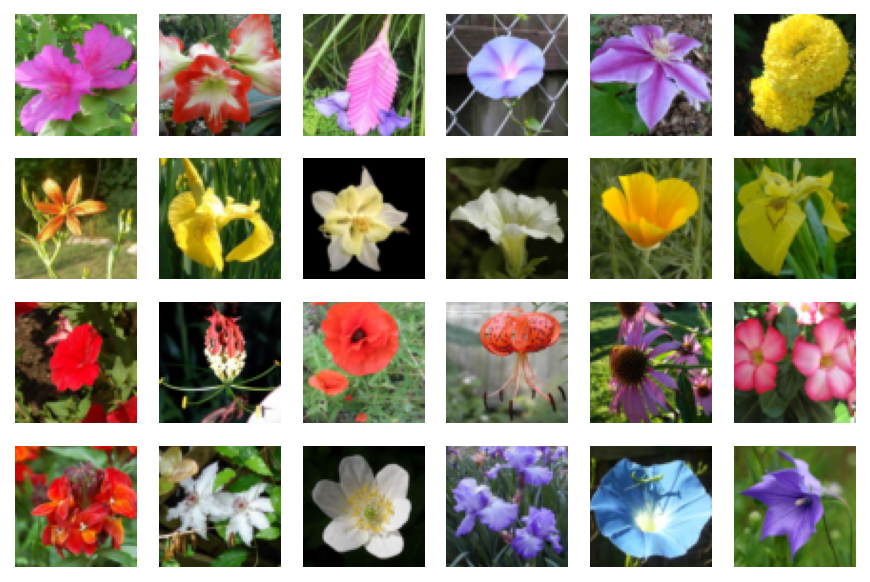

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.9,batch_size),dpi=150)
for col in range(6):    #Plots sample images in four rows and six columns
    imgs=next(iter(train_dataloader))["input"]
    for row in range(batch_size):
        plt.subplot(batch_size,6,col+1+row*6)
        img=imgs[row].permute(1,2,0)    #Changes from channel first to channel last
        plt.imshow(torch.clip(img,0,1))    #Clips image values so they fall in the range [0, 1]
        plt.axis('off')
plt.tight_layout()
plt.show()

We plot $24$ sample images in a $4 \times 6$ grid. PyTorch uses channel-first tensors to represent
images, so we use the `permute()` method to change the tensors to channel-last
format before displaying them.

These are color images of various types of flowers.
We have standardized the size of each image to $(3, 64, 64)$ so that we can place them in
batches to feed to the model.

## 2.2.	Applying forward diffusion on flower images


Next, we apply the DDIM noise scheduler on the clean flower images to add noise
to them so that we can use the noisy images to train our model.

First, we define a class `DDIMScheduler()` to model the DDIM.

In [ ]:
import math
from typing import Union

import numpy as np
from tqdm import tqdm


def normalize_to_neg_one_to_one(img):
    return img * 2 - 1


def unnormalize_to_zero_to_one(t):
    return (t + 1) * 0.5


def match_shape(values, broadcast_array, tensor_format="pt"):
    values = values.flatten()

    while len(values.shape) < len(broadcast_array.shape):
        values = values[..., None]
    if tensor_format == "pt":
        values = values.to(broadcast_array.device)

    return values


def clip(tensor, min_value=None, max_value=None):
    if isinstance(tensor, np.ndarray):
        return np.clip(tensor, min_value, max_value)
    elif isinstance(tensor, torch.Tensor):
        return torch.clamp(tensor, min_value, max_value)

    raise ValueError("Tensor format is not valid is not valid - " \
        f"should be numpy array or torch tensor. Got {type(tensor)}.")


def cosine_beta_schedule(timesteps, beta_start, beta_end, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float32)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, beta_start, beta_end)


class DDIMScheduler:
    def __init__(
        self,
        num_train_timesteps=1000,
        beta_start=0.0001,
        beta_end=0.02,
        beta_schedule="cosine",
        clip_sample=True,
        set_alpha_to_one=True
    ):

        if beta_schedule == "linear":
            self.betas = np.linspace(beta_start, beta_end, num_train_timesteps, dtype=np.float32)
        elif beta_schedule == "cosine":
            self.betas = cosine_beta_schedule(num_train_timesteps,
                                              beta_start=beta_start,
                                              beta_end=beta_end)
        else:
            raise NotImplementedError(
                f"{beta_schedule} does is not implemented for {self.__class__}")

        self.num_train_timesteps = num_train_timesteps
        self.clip_sample = clip_sample
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.final_alpha_cumprod = np.array(1.0) if set_alpha_to_one else self.alphas_cumprod[0]

        self.num_inference_steps = None
        self.timesteps = np.arange(0, num_train_timesteps)[::-1].copy()

    def _get_variance(self, timestep, prev_timestep):
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[
            prev_timestep] if prev_timestep >= 0 else self.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)

        return variance

    def set_timesteps(self, num_inference_steps, offset=0):
        self.num_inference_steps = num_inference_steps
        self.timesteps = np.arange(0, 1000, 1000 // num_inference_steps)[::-1].copy()
        self.timesteps += offset

    def step(
        self,
        model_output: Union[torch.FloatTensor, np.ndarray],
        timestep: int,
        sample: Union[torch.FloatTensor, np.ndarray],
        eta: float = 1.0,
        use_clipped_model_output: bool = True,
        generator=None,
    ):
        # 1. get previous step value (=t-1)
        prev_timestep = timestep - self.num_train_timesteps // self.num_inference_steps

        # 2. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[
            prev_timestep] if prev_timestep >= 0 else self.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t

        # 3. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
        pred_original_sample = (sample - beta_prod_t**(0.5) * model_output) / alpha_prod_t**(0.5)

        # 4. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = clip(pred_original_sample, -1, 1)

        # 5. compute variance: "sigma_t(η)" -> see formula (16)
        # σ_t = sqrt((1 − α_t−1)/(1 − α_t)) * sqrt(1 − α_t/α_t−1)
        variance = self._get_variance(timestep, prev_timestep)
        std_dev_t = eta * variance**(0.5)

        if use_clipped_model_output:
            # the model_output is always re-derived from the clipped x_0 in Glide
            model_output = (sample -
                            alpha_prod_t**(0.5) * pred_original_sample) / beta_prod_t**(0.5)

        # 6. compute "direction pointing to x_t" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
        pred_sample_direction = (1 - alpha_prod_t_prev - std_dev_t**2)**(0.5) * model_output

        # 7. compute x_t without "random noise" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
        prev_sample = alpha_prod_t_prev**(0.5) * pred_original_sample + pred_sample_direction

        if eta > 0:
            device = model_output.device if torch.is_tensor(model_output) else "cpu"
            noise = torch.randn(model_output.shape, generator=generator).to(device)
            variance = self._get_variance(timestep, prev_timestep)**(0.5) * eta * noise

            if not torch.is_tensor(model_output):
                variance = variance.numpy()

            prev_sample = prev_sample + variance

        return prev_sample

    def add_noise(self, original_samples, noise, timesteps):
        timesteps = timesteps.cpu()
        sqrt_alpha_prod = self.alphas_cumprod[timesteps]**0.5
        sqrt_alpha_prod = match_shape(sqrt_alpha_prod, original_samples)
        sqrt_one_minus_alpha_prod = (1 - self.alphas_cumprod[timesteps])**0.5
        sqrt_one_minus_alpha_prod = match_shape(sqrt_one_minus_alpha_prod, original_samples)

        noisy_samples = sqrt_alpha_prod * original_samples + sqrt_one_minus_alpha_prod * noise
        return noisy_samples

    @torch.no_grad()
    def generate(self,model,device,batch_size=1,generator=None,
         eta=1.0,use_clipped_model_output=True,num_inference_steps=50):
        # Create a list to store intermediate images
        imgs=[]
        # Generate the initial random noise tensor
        image=torch.randn((batch_size,model.in_channels,model.sample_size,
            model.sample_size),generator=generator).to(device)
        self.set_timesteps(num_inference_steps)
        # Iteratively denoise the image using the trained U-Net model
        for t in tqdm(self.timesteps):
            model_output = model(image, t)["sample"]
            image = self.step(model_output,t,image,eta,
                  use_clipped_model_output=use_clipped_model_output)
            img = unnormalize_to_zero_to_one(image)
            img = img.cpu().permute(0, 2, 3, 1).numpy()
            imgs.append(img)
        # Output the final clean image and the intermediate noisy images
        image = unnormalize_to_zero_to_one(image)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        return image, imgs

    @torch.no_grad()
    def interpolate(self,model,a_idx,b_idx,batch_size=1,generator=None,
        eta=1.0,use_clipped_model_output=True,num_inference_steps=50,
                 device=None):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        image0 = torch.randn((batch_size, model.in_channels,
          model.sample_size, model.sample_size),generator=generator,
                             ).to(device)
        image = torch.zeros((batch_size, model.in_channels,
          model.sample_size, model.sample_size)).to(device)
        # Pick two initial noise tensors
        a,b=image0[a_idx],image0[b_idx]
        # Create 10 interpolated noise tensors by placing different weights on the 2 noise tensors
        for i in range(10):
            ab=torch.sin(torch.tensor(0.5*math.pi*(0.05+i/10)))*a+\
                torch.cos(torch.tensor(0.5*math.pi*(0.05+i/10)))*b
            image[i]=ab
        self.set_timesteps(num_inference_steps)
        # Generate images by iteratively denoising the interpolated noise tensors
        for t in tqdm(self.timesteps):
            model_output = model(image, t)["sample"]
            image = self.step(model_output,t,image,eta,
              use_clipped_model_output=use_clipped_model_output,
                              generator=generator)
        image = unnormalize_to_zero_to_one(image)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        return image

    def __len__(self):
        return self.num_train_timesteps

Then, we will add noise
to several images to visualize how the forward diffusion process works in DDIM.

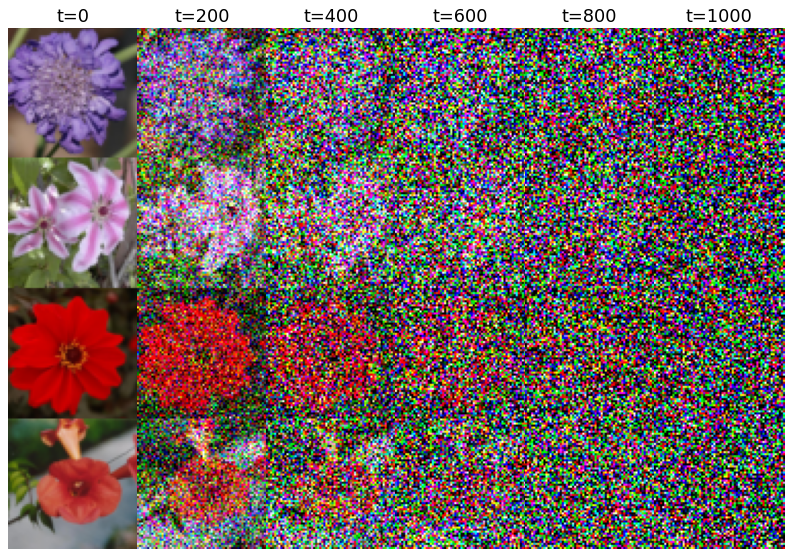

In [ ]:
noise_scheduler=DDIMScheduler(num_train_timesteps=1000)

imgs=next(iter(train_dataloader))["input"]
imgs=imgs.permute(0,2,3,1).reshape(-1,64,3)    #Obtains a batch of images and change them to channel-last format

allimgs=[imgs]
for step in [200,400,600,800,1000]:    #Creates noisy images at time steps 200, 400, ..., 1000
    timesteps=torch.tensor([step-1]).long()
    noisy_image=noise_scheduler.add_noise(imgs,
         torch.randn(imgs.shape), timesteps)
    allimgs.append(noisy_image)
plt.figure(figsize=(10,8),dpi=80)
for i in range(6):    #Plots them iamges in a 4x6 grid
    plt.subplot(1,6,i+1)
    plt.imshow(torch.clip(allimgs[i],0,1))
    plt.axis('off')
    plt.title(f"t={200*i}",fontsize=16)
plt.tight_layout(w_pad=-0.1)
plt.show()

We use $T = 1,000$ time steps in the forward diffusion process, in which noise is gradually
added to the images. The left column is time step 0, when the four images are the
original clean images, without any noise added to them. The second column shows
images in time step $200$, when some noise is added to the images. As we move to the
right, more and more noise is added to the images, until at time step $T = 1,000$, the
four images become pure random noise.

Now that we have the training data ready, we will build and train a denoising model to
generate high-resolution flower images that resemble those in the training set.

# 3. Building and training a U-Net model for high-resolution images

In this section, we build a denoising U-Net model that integrates the attention mechanism
discussed earlier in the laboratory. Our U-Net model is large, comprising more than
133 million parameters. It features multiple convolutional layers connected through
skip connections, which merge features from different network levels. This design preserves
spatial information, enhancing the model's learning capability.

Due to the model's large size and redundant feature extraction, we incorporate the
SDPA attention mechanism to focus on the most relevant aspects of the input. To compute
SDPA attention, we flatten the image, treating its pixels as a sequence. This allows
SDPA to capture dependencies among pixels, similar to how we modeled token relationships
in text in Laboratory 1. Finally, we train the model using the flower images prepared
earlier.

## 3.1. Building the denoising U-Net model

The diffusion model we construct is an unconditional model, meaning it generates
flower images without any labeling information. As a result, the model can produce
an image of a flower from any category in the training set, such as a lily, aster, peony,
or other types. Unlike the conditional model we discussed in the previous laboratory, the
U-Net in this laboratory only embeds time step information and doesn't incorporate class
labels.

We start off by defining a `sinusoidal_embedding()` function, as follows, to embed the time step information:

In [ ]:
def sinusoidal_embedding(timesteps, dim):
    half_dim = dim // 2
    exponent = -math.log(10000) * torch.arange(
        start=0, end=half_dim, dtype=torch.float32)
    exponent = exponent / (half_dim - 1.0)
    emb = torch.exp(exponent).to(device=timesteps.device)
    emb = timesteps[:, None].float() * emb[None, :]
    return torch.cat([emb.sin(), emb.cos()], dim=-1) #In fixed positional encoding, the sine function applies to even positions and the cosine function to odd positions.

We use fixed positional encoding here, similar to what we did in Laboratory 1, instead of
the learned positional encoding we used in Laboratory 2. Because we have a large model, fixed positional encoding reduces the number of learnable parameters, which can
speed up the training process. To implement the attention mechanism, we define an `Attention` class, as shown below:

In [ ]:
from torch import nn, einsum

from einops import rearrange

class Attention(nn.Module):

    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads

        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads),
            qkv)

        q = q * self.scale

        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        attn = sim.softmax(dim=-1)
        out = einsum('b h i j, b h d j -> b h i d', attn, v)

        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)

This is the standard SDPA attention mechanism that we often use in Transformers and
natural language processing (NLP). Specifically, we first pass the input through three
linear layers to obtain query, key, and value. We then split the query, key, and value tensors
into four heads and calculate the attention in each head. Finally, we concatenate
the four attention tensors from the four heads into one single attention tensor as the
final output. We create a denoising U-Net model as follows:

In [ ]:
from torch.nn import functional as F
from einops.layers.torch import Rearrange


def get_downsample_layer(in_dim, hidden_dim, is_last):
    if not is_last:
        return nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
            nn.Conv2d(in_dim * 4, hidden_dim, 1))
    else:
        return nn.Conv2d(in_dim, hidden_dim, 3, padding=1)


def get_attn_layer(in_dim, is_last):
    if is_last:
        return Residual(PreNorm(in_dim, Attention(in_dim)))
    else:
        return nn.Identity()


def get_upsample_layer(in_dim, hidden_dim, is_last):
    if not is_last:
        return nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'),
                             nn.Conv2d(in_dim, hidden_dim, 3, padding=1))
    else:
        return nn.Conv2d(in_dim, hidden_dim, 3, padding=1)


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class LayerNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))

    def forward(self, x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) * (var + eps).rsqrt() * self.g


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class ResidualBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 temb_channels,
                 kernel_size=3,
                 stride=1,
                 padding=1,
                 groups=8):
        super(ResidualBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.time_emb_proj = nn.Sequential(
            nn.SiLU(), torch.nn.Linear(temb_channels, out_channels))

        self.residual_conv = nn.Conv2d(
            in_channels, out_channels=out_channels,
            kernel_size=1) if in_channels != out_channels else nn.Identity()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)

        self.norm1 = nn.GroupNorm(num_channels=out_channels, num_groups=groups)
        self.norm2 = nn.GroupNorm(num_channels=out_channels, num_groups=groups)
        self.nonlinearity = nn.SiLU()

    def forward(self, x, temb):
        residual = self.residual_conv(x)

        x = self.conv1(x)
        x = self.norm1(x)
        x = self.nonlinearity(x)

        temb = self.time_emb_proj(self.nonlinearity(temb))
        x += temb[:, :, None, None]

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.nonlinearity(x)

        return x + residual


class UNet(nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_dims=[128, 256, 512, 1024],
                 image_size=64):
        super(UNet, self).__init__()

        self.sample_size = image_size
        self.in_channels = in_channels
        self.hidden_dims = hidden_dims

        timestep_input_dim = hidden_dims[0]
        time_embed_dim = timestep_input_dim * 4

        self.time_embedding = nn.Sequential(
            nn.Linear(timestep_input_dim, time_embed_dim), nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim))

        self.init_conv = nn.Conv2d(in_channels,
                                   out_channels=hidden_dims[0],
                                   kernel_size=3,
                                   stride=1,
                                   padding=1)

        down_blocks = []

        in_dim = hidden_dims[0]
        for idx, hidden_dim in enumerate(hidden_dims[1:]):
            is_last = idx >= (len(hidden_dims) - 2)
            down_blocks.append(
                nn.ModuleList([
                    ResidualBlock(in_dim, in_dim, time_embed_dim),
                    ResidualBlock(in_dim, in_dim, time_embed_dim),
                    get_attn_layer(in_dim, is_last),
                    get_downsample_layer(in_dim, hidden_dim, is_last)
                ]))
            in_dim = hidden_dim

        self.down_blocks = nn.ModuleList(down_blocks)

        mid_dim = hidden_dims[-1]
        self.mid_block1 = ResidualBlock(mid_dim, mid_dim, time_embed_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = ResidualBlock(mid_dim, mid_dim, time_embed_dim)

        up_blocks = []
        in_dim = mid_dim
        for idx, hidden_dim in enumerate(list(reversed(hidden_dims[:-1]))):
            is_last = idx >= (len(hidden_dims) - 2)
            up_blocks.append(
                nn.ModuleList([
                    ResidualBlock(in_dim + hidden_dim, in_dim, time_embed_dim),
                    ResidualBlock(in_dim + hidden_dim, in_dim, time_embed_dim),
                    get_attn_layer(in_dim, is_last),
                    get_upsample_layer(in_dim, hidden_dim, is_last)
                ]))
            in_dim = hidden_dim

        self.up_blocks = nn.ModuleList(up_blocks)

        self.out_block = ResidualBlock(hidden_dims[0] * 2, hidden_dims[0],
                                       time_embed_dim)
        self.conv_out = nn.Conv2d(hidden_dims[0], out_channels=3, kernel_size=1)

    def forward(self, sample, timesteps):
        if not torch.is_tensor(timesteps):
            timesteps = torch.tensor([timesteps],
                                     dtype=torch.long,
                                     device=sample.device)

        timesteps = torch.flatten(timesteps)
        timesteps = timesteps.broadcast_to(sample.shape[0])

        t_emb = sinusoidal_embedding(timesteps, self.hidden_dims[0])
        t_emb = self.time_embedding(t_emb)

        x = self.init_conv(sample)
        r = x.clone()

        skips = []
        for block1, block2, attn, downsample in self.down_blocks:
            x = block1(x, t_emb)
            skips.append(x)

            x = block2(x, t_emb)
            x = attn(x)
            skips.append(x)

            x = downsample(x)

        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        for block1, block2, attn, upsample in self.up_blocks:
            x = torch.cat((x, skips.pop()), dim=1)
            x = block1(x, t_emb)

            x = torch.cat((x, skips.pop()), dim=1)
            x = block2(x, t_emb)
            x = attn(x)

            x = upsample(x)

        x = self.out_block(torch.cat((x, r), dim=1), t_emb)
        out = self.conv_out(x)
        return {"sample": out}

We instantiate the `UNet` class to
create a denoising U-Net model. We count the total number of model parameters. The output shows that there are more than 133 million parameters.

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
resolution=64
model=UNet(3,hidden_dims=[128,256,512,1024],
           image_size=resolution).to(device) #Instantiates the UNet class to create a denoising U-Net model
num=sum(p.numel() for p in model.parameters())
print("number of parameters: %.2fM" % (num/1e6,)) #Counts the number of model parameters

number of parameters: 133.42M


## 3.2. Training the denoising U-Net model

During each training epoch, we iterate through all batches in the training dataset. For
each image, we randomly select a time step and introduce noise to the clean image
based on this value, generating a noisy version. These noisy images, along with their
corresponding time step values, are then passed into the denoising U-Net model,
which predicts the added noise. The predicted noise is compared to the ground truth
(the actual noise introduced), and the model parameters are updated to minimize the
mean absolute error between them.

To optimize the model, we use the AdamW optimizer, a variant of the Adam optimizer
employed throughout this laboratory. Additionally, we implement a learning rate
scheduler from the `diffusers` library to dynamically adjust the learning rate during
training. Using a higher initial learning rate helps the model escape local minima,
while gradually reducing it in later stages promotes stable convergence toward a global
minimum. The learning rate scheduler is defined as shown here:

In [ ]:
from diffusers.optimization import get_scheduler

optimizer=torch.optim.AdamW(model.parameters(),lr=0.0001,
    betas=(0.95,0.999),weight_decay=0.00001,eps=1e-8)    #Uses the AdamW optimizer
lr_scheduler=get_scheduler(    #Uses the learning rate scheduler from the diffusers library
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=300,
    num_training_steps=(len(train_dataloader) * 100))

For simplicity, we train the model for $1$ epoch, as shown below. We can use early stopping to determine how many epochs to train, as we did in Laboratory
2. We print out the average loss during the training process.

In [ ]:
#16min
for epoch in range(1):
    model.train()
    tloss = 0
    print(f"start epoch {epoch}")
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["input"].to(device)*2-1
        nums = clean_images.shape[0]
        noise = torch.randn(clean_images.shape).to(device)
        timesteps = torch.randint(0,
                noise_scheduler.num_train_timesteps,
                (nums, ),
                device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images,
                     noise, timesteps)

        noise_pred = model(noisy_images, timesteps)["sample"]
        loss = torch.nn.functional.l1_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        tloss += loss.detach().item()
        if step%100==0:
            print(f"step {step}, average loss {tloss/(step+1)}")
torch.save(model.state_dict(),'files/diffusion.pth')

start epoch 0
step 0, average loss 0.09800969064235687
step 100, average loss 0.1540046855069623
step 200, average loss 0.15143819138481843
step 300, average loss 0.15002018345699358
step 400, average loss 0.15182432441268479
step 500, average loss 0.1508435323507248
step 600, average loss 0.1518970191503523
step 700, average loss 0.15243106955574684
step 800, average loss 0.15264385611693213
step 900, average loss 0.15314733593432145
step 1000, average loss 0.15258678785719715
step 1100, average loss 0.15298976472407227
step 1200, average loss 0.15256185261385327
step 1300, average loss 0.15263909792139566
step 1400, average loss 0.1523756416571685
step 1500, average loss 0.15236892859680426
step 1600, average loss 0.15234155935013688
step 1700, average loss 0.15204356995349347
step 1800, average loss 0.15241621948493184
step 1900, average loss 0.15206248995929816
step 2000, average loss 0.15216960659672296


After training, the trained model weights are saved in the `files` folder. Alternatively, the trained weights can be downloaded from Google Drive at https://drive.google.com/file/d/1l_myHJ5y2Y7U3haJTn0lajKAiQtxG3jv/view?usp=drive_link. Unzip the file after downloading.

# 4. Image generation and interpolation

With the denoising U-Net model now trained, we can use it to generate flower images.
The generation process unfolds over $50$ inference steps, where we set the time step values
to $980$, $960$, . . ., $20$, and $0$. The image starts as pure random noise, and we feed it into
the trained model to produce a slightly denoised image. This output is then iteratively
refined by feeding it to the model again, gradually reducing noise over $50$ reference
steps until we obtain a final image that closely resembles the flowers in the training set.

Beyond generating individual images, we will also explore how to interpolate between
two initial noise tensors. This technique enables us to create a smooth transition
between two images, producing a series of intermediate images that visually morph
from one flower to another.

## 4.1. Using the trained denoising U-Net to generate images

Now we can generate the flower images. To do so, we use the `generate()` method defined in the `DDIMScheduler` class.

The `generate()` method feeds a random noise tensor to the trained model to denoise
it iteratively. The function returns the final clean image as well as the intermediate
noisy images. In the following code, we use the trained denoising U-Net and the `generate()` method to create $10$ flower images.

 98%|█████████▊| 49/50 [00:16<00:00,  2.96it/s]/tmp/ipykernel_7720/1349074058.py:84: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
100%|██████████| 50/50 [00:16<00:00,  2.99it/s]


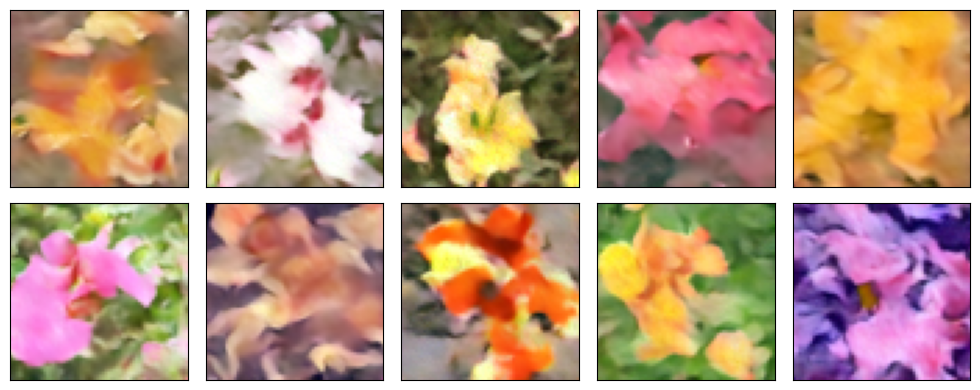

In [ ]:
sd=torch.load('files/diffusion.pth',weights_only=True)

model.load_state_dict(sd) #Loads the trained model parameters
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images,imgs = noise_scheduler.generate(
        model,device=device,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10) #Generates 10 flower images using the trained model
imgnp=generated_images

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10): #Plots the generated images in a 2 × 5 grid
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

Because we use an unconditional diffusion model, the images are generated without
labeling information. The $10$ images above are of different types, but they do
look similar to those in the training set.

If we are wondering whether we can control which flower images the trained model
generates, the answer is yes. Each initial noise tensor produces a unique flower image.
In the next subsection, we will explore how to choose different noise tensors to generate
specific images. Even better, we will learn how to interpolate between noise tensors to
create composite images.

## 4.2. Transition from one image to another

When we generate flower images with the trained U-Net, the denoising process is influenced
by the initial noise tensor we provide. Different noise tensors lead to different
final images. Next, we will interpolate between two noise tensors by blending them in
varying proportions to create new noise tensors. We then feed the interpolated noise
tensors to the U-Net to generate a series of images that transition from one image to
another. To that end, we have defined the `interpolate()` method in the `DDIMScheduler` class.

The `a_idx` and `b_idx` arguments in the `interpolate()` method determine which two
initial noise tensors to use. If we fix the random state, the two arguments lead to two
specific flower images. By applying different weightings to these initial tensors, we generate
$10$ interpolated noise tensors. These interpolated tensors are then fed into the
trained model to produce a sequence of interpolated images. Now we create a series
of interpolated images using the `interpolate()` method.

 98%|█████████▊| 49/50 [00:14<00:00,  3.25it/s]/tmp/ipykernel_7720/1349074058.py:84: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
100%|██████████| 50/50 [00:15<00:00,  3.30it/s]


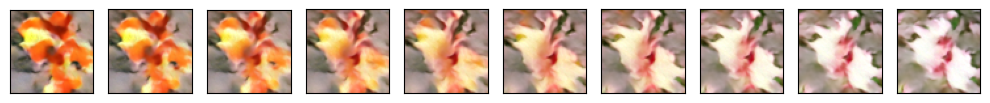

In [ ]:
with torch.no_grad():
    generator = torch.manual_seed(100) #Fixes the random state to 100
    generated_images = noise_scheduler.interpolate(
        model,1,7, #Chooses the second and the eighth initial noise tensors
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)

imgnp=generated_images

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10):
    ax = plt.subplot(1,10, i + 1) #Plots the 10 interpolated images based on the two initial noise tensors
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

Note that we have fixed the random state to `100`, the same random state we used above. Therefore, by setting `a_idx=1` and `b_idx=7` in the `interpolate()` method, we are
using the same two initial noise tensors that produce images 2 and 8 in Section 4.1.

Because the $10$ images in Section 4.1 are also generated by fixing the random state to
`100`, the right image in the figure above looks similar to the second image in Section 4.1, while the left image looks similar to the eighth image in Section 4.1.

Finally, we generate three more sets of interpolated images. The following code shows
how.

In [ ]:
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,2,5, #Interpolates using the third and sixth initial noise tensors
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp1=generated_images
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,7,2, #Interpolates using the eighth and third initial noise tensors
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp2=generated_images
with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(
        model,3,1, #Interpolates using the fourth and second initial noise tensors
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp3=generated_images

 98%|█████████▊| 49/50 [00:14<00:00,  3.14it/s]/tmp/ipykernel_7720/1349074058.py:84: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
100%|██████████| 50/50 [00:15<00:00,  3.18it/s]


We first generate a set of $10$ interpolated images using the third and sixth initial noise
tensors. We then create another set using the eighth and third initial noise tensors.
Finally, a third set of interpolated images are created using the fourth and second initial
noise tensors. These three sets of images are saved as NumPy arrays, `imgnp1`, `imgnp2`,
and `imgnp3`, respectively. Next, we plot them in three rows, like this:

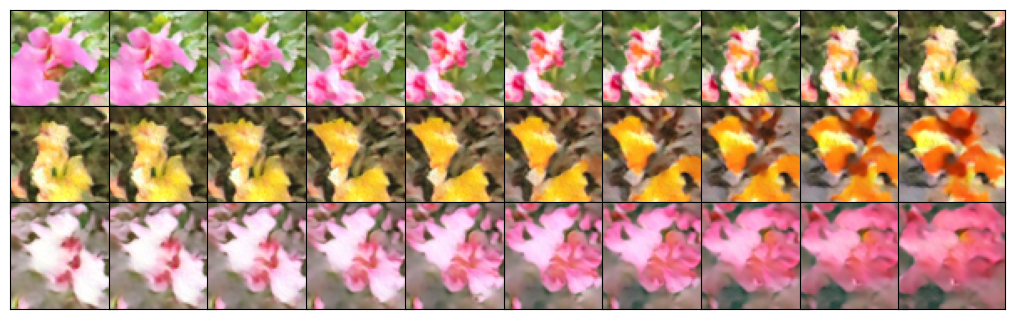

In [ ]:
import numpy as np
img_array=np.concatenate([imgnp1,imgnp2,imgnp3]) #Concatenates the three sets of images
fig, axs = plt.subplots(nrows=3,
            ncols=10,sharex=True,
            sharey=True,figsize=(10,3),dpi=100)
for row in range(3): #Plots the images in a 3 × 10 grid
    for col in range(10):
        axs[row, col].clear()
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        axs[row, col].imshow(img_array[col+row*10])
plt.subplots_adjust(bottom=0.001,right=0.999,top=0.999,
left=0.001, hspace=-0.1,wspace=-0.1)

After running the preceding code block, we will see sets of images as shown above. With the random state set to `100`, we select three pairs of initial noise tensors to
generate interpolated noise tensors by applying varying weightings to the originals.

These initial tensors are passed through the trained U-Net to generate interpolated
images, as shown above. In each row, as we go from left to right, the image
smoothly transitions from the leftmost image to the rightmost image.

#Exercises

1.   Plot images from the training set in a $2 \times 5$ grid.

2.   Modify the code for applying forward diffusion to flower images. Use four images from the training set to generate images in
time steps $0$, $250$, $500$, $750$, and $1,000$. Plot them in a $4 \times 5$ grid.



3.   Modify the code for image generation with the trained denoising U-Net, and change the random seed to $42$. Keep the rest of the code
the same. Rerun the code to see what the generated images look like.


4.   Modify the code for interpolating initial noise tensors to use the third and fourth initial noise tensors to generate $10$
interpolated images. Keep the rest of the code the same (in particular, keep the random
state to $100$). Rerun the code to see what the generated images look like.

